In [172]:
library(tidyverse)
library(dplyr)
library(broom)
library(ggplot2)
library(car)
library(GGally)
library(broom)

In [173]:
property <- read.csv(
  file = "./data/sample_data.csv"
) |>
  subset(select = c(CURRENT_LAND_VALUE,
    PREVIOUS_LAND_VALUE,
    PREVIOUS_IMPROVEMENT_VALUE,
    YEAR_BUILT, ZONING_CLASSIFICATION
  )) |>
  na.omit()

  property2 <- subset(property,
  is.finite(CURRENT_LAND_VALUE) & CURRENT_LAND_VALUE > 0 &
  is.finite(PREVIOUS_LAND_VALUE) & PREVIOUS_LAND_VALUE > 0 &
  is.finite(PREVIOUS_IMPROVEMENT_VALUE) & PREVIOUS_IMPROVEMENT_VALUE > 0 &
  is.finite(YEAR_BUILT)
)

sample_n(property, 10)

CURRENT_LAND_VALUE,PREVIOUS_LAND_VALUE,PREVIOUS_IMPROVEMENT_VALUE,YEAR_BUILT,ZONING_CLASSIFICATION
<dbl>,<dbl>,<int>,<int>,<chr>
452000,407000,66400,1977,Multiple Dwelling
424000,403000,37100,1974,Multiple Dwelling
1579000,1674000,275000,1994,Residential Inclusive
3904000,6243000,297000,1965,Commercial
543000,461000,156000,1991,Residential
505000,549000,181000,2009,Comprehensive Development
1569000,1744000,88800,1908,Residential
2274000,1897000,391000,1995,One-Family Dwelling
1235000,1266000,409000,2018,Comprehensive Development


In [174]:
# See how many variables in ZONING CLASSIFICATION

unique(property$ZONING_CLASSIFICATION)
length(unique(property$ZONING_CLASSIFICATION))

[1] "Residential Inclusive"     "One-Family Dwelling"      
 [3] "Comprehensive Development" "Industrial"               
 [5] "Commercial"                "Multiple Dwelling"        
 [7] "Residential"               "Two-Family Dwelling"      
 [9] "Historical Area"           "Other"                    
[11] ""                          "Limited Agriculture"

[1] 12

In [175]:
# See what missing values in ZONING CLASSIFICATION

property[property$ZONING_CLASSIFICATION == '',]

,CURRENT_LAND_VALUE,PREVIOUS_LAND_VALUE,PREVIOUS_IMPROVEMENT_VALUE,YEAR_BUILT,ZONING_CLASSIFICATION
,<dbl>,<dbl>,<int>,<int>,<chr>
175,537000,609000,145000,2017,
605,320000,310000,166000,2018,
991,1523000,1811000,126000,1983,
1511,494000,551000,298000,2018,
1676,520000,503000,281000,2018,
1890,300000,350000,187000,2018,
1946,420000,491000,261000,2018,
1985,732000,822000,349000,2017,


In [176]:
# Simplify ZONING CLASSIFICATION into 5 categories: Residential, Commercial, Industrial, Agriculture, Special

property2$ZONE_SIMPLE <- dplyr::case_when(
  property2$ZONING_CLASSIFICATION %in% c(
    "Residential Inclusive",
    "One-Family Dwelling",
    "Two-Family Dwelling",
    "Multiple Dwelling",
    "Residential"
  ) ~ "Residential",

  property2$ZONING_CLASSIFICATION == "Commercial" ~ "Commercial",

  property2$ZONING_CLASSIFICATION == "Industrial" ~ "Industrial",

  property2$ZONING_CLASSIFICATION == "Limited Agriculture" ~ "Agriculture",
  property2$ZONING_CLASSIFICATION %in% c(
    "Comprehensive Development",
    "Historical Area",
    "",
    "Other"
  ) ~ "Special"
)

In [177]:
unique(property$ZONE_SIMPLE)
length(unique(property$ZONE_SIMPLE))

NULL

[1] 0

In [178]:
colSums(is.na(property))

CURRENT_LAND_VALUE        PREVIOUS_LAND_VALUE 
                         0                          0 
PREVIOUS_IMPROVEMENT_VALUE                 YEAR_BUILT 
                         0                          0 
     ZONING_CLASSIFICATION 
                         0

In [179]:
fit <- lm(log(CURRENT_LAND_VALUE) ~ log(PREVIOUS_LAND_VALUE) + log(PREVIOUS_IMPROVEMENT_VALUE) + YEAR_BUILT + ZONE_SIMPLE, data = property2)
bb <- coef(fit)

# bb
summary(fit)


Call:
lm(formula = log(CURRENT_LAND_VALUE) ~ log(PREVIOUS_LAND_VALUE) + 
    log(PREVIOUS_IMPROVEMENT_VALUE) + YEAR_BUILT + ZONE_SIMPLE, 
    data = property2)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.59795 -0.05408  0.00553  0.05932  0.62958 

Coefficients:
                                  Estimate Std. Error t value Pr(>|t|)    
(Intercept)                      1.0132292  0.2159266   4.692 2.89e-06 ***
log(PREVIOUS_LAND_VALUE)         0.9778953  0.0030995 315.506  < 2e-16 ***
log(PREVIOUS_IMPROVEMENT_VALUE)  0.0072486  0.0024881   2.913  0.00362 ** 
YEAR_BUILT                      -0.0003358  0.0001042  -3.222  0.00130 ** 
ZONE_SIMPLECommercial           -0.1275848  0.0998699  -1.278  0.20158    
ZONE_SIMPLEIndustrial           -0.1172861  0.1006505  -1.165  0.24405    
ZONE_SIMPLEResidential          -0.1051328  0.0993653  -1.058  0.29017    
ZONE_SIMPLESpecial              -0.1439204  0.0996020  -1.445  0.14864    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '

In [180]:
vif(fit)

,GVIF,Df,GVIF^(1/(2*Df))
log(PREVIOUS_LAND_VALUE),1.910710,1,1.382284
log(PREVIOUS_IMPROVEMENT_VALUE),1.741281,1,1.319576
YEAR_BUILT,1.951691,1,1.397029
ZONE_SIMPLE,1.676039,4,1.066683


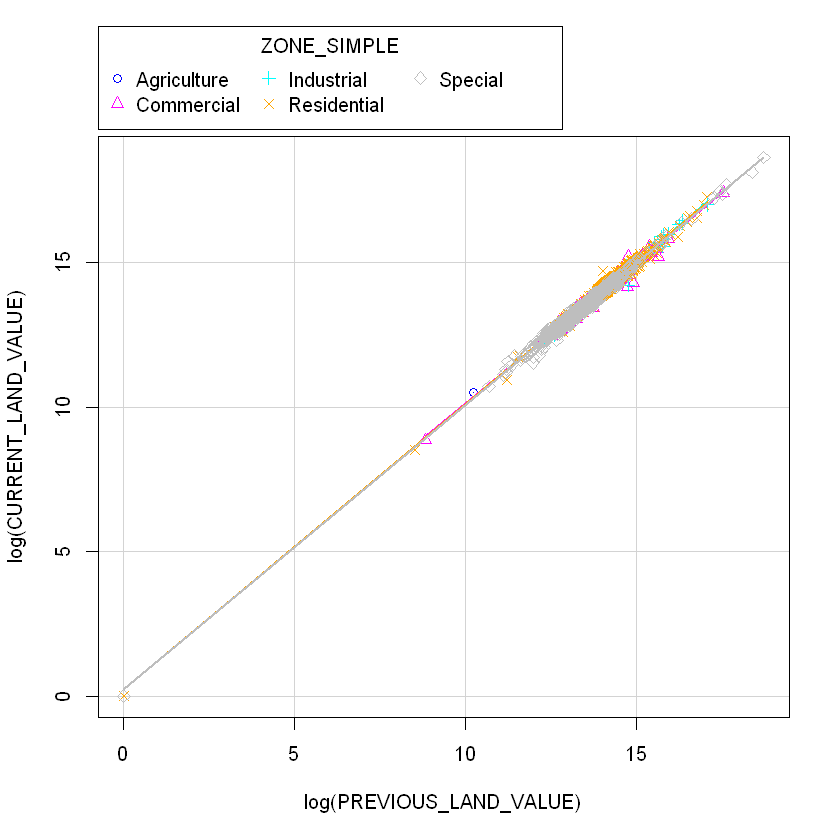

In [181]:
scatterplot(log(CURRENT_LAND_VALUE) ~ log(PREVIOUS_LAND_VALUE)|ZONE_SIMPLE, smooth=FALSE, by.groups=TRUE, data=property2)

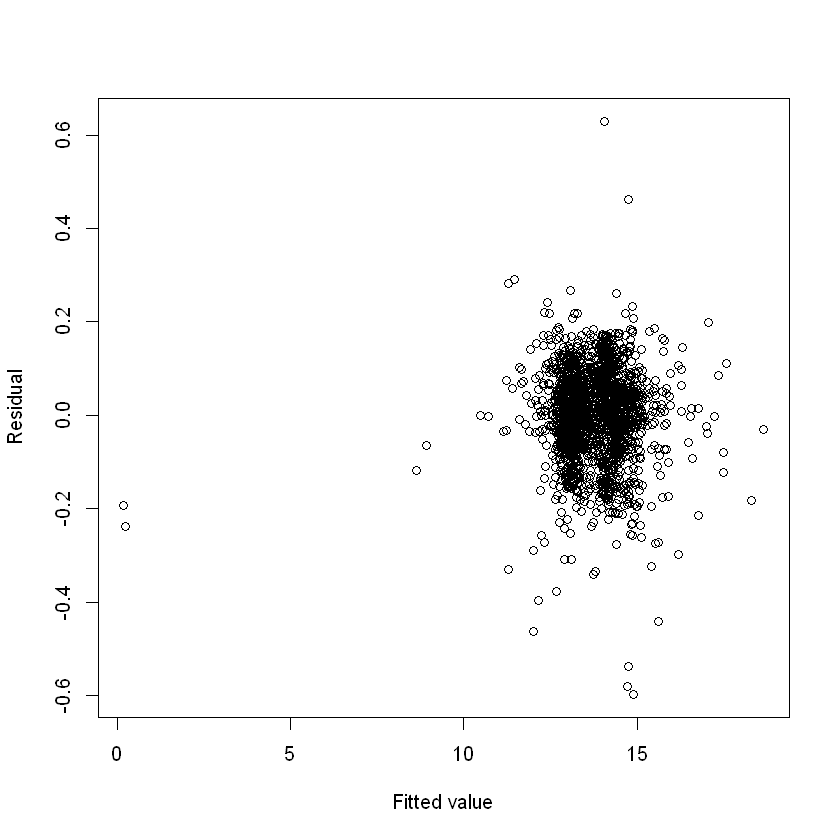

In [182]:
plot(fit$fitted.values, fit$residuals, xlab="Fitted value", ylab="Residual")

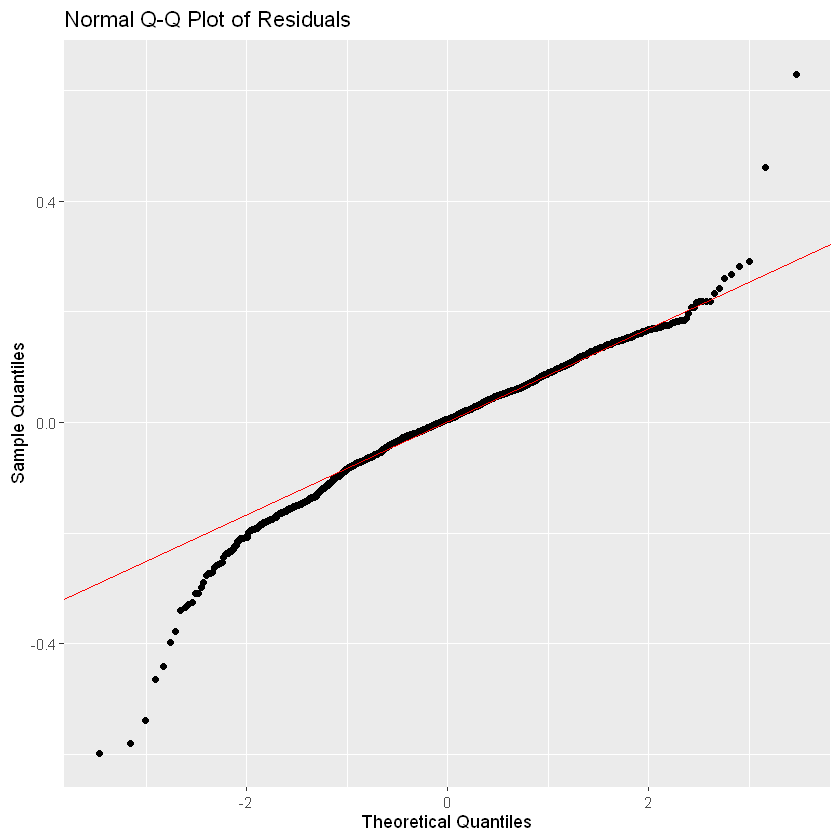

In [184]:
# ggplot2
ggplot(data.frame(resid = residuals(fit)), aes(sample = resid)) +
  stat_qq() +
  stat_qq_line(color = "red") +
  labs(
    title = "Normal Q-Q Plot of Residuals",
    x = "Theoretical Quantiles",
    y = "Sample Quantiles"
  )

`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


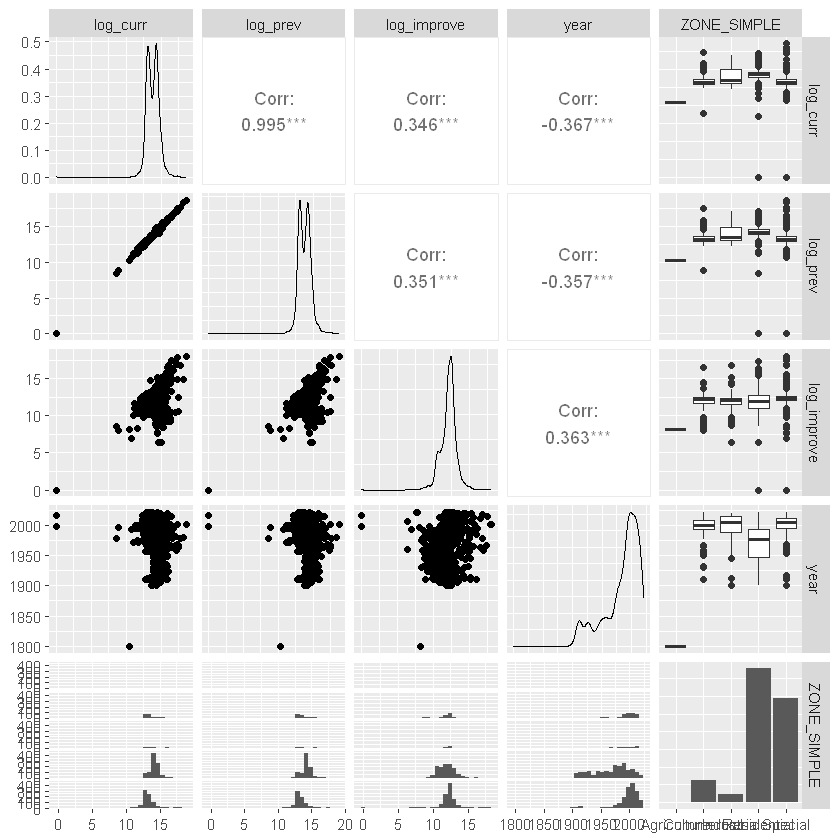

In [185]:
property_log <- property2 |>
                mutate(log_curr = log(CURRENT_LAND_VALUE),
                log_prev = log(PREVIOUS_LAND_VALUE),
                log_improve = log(PREVIOUS_IMPROVEMENT_VALUE),
                year = as.numeric(YEAR_BUILT)) |>
                select(log_curr, log_prev, log_improve, year, ZONE_SIMPLE)
ggpairs(property_log)